<a href="https://colab.research.google.com/github/KavindaKGD/DL_Final_Assignment/blob/dev%2FKavinda/VGG16_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os, shutil, zipfile, random, pathlib, glob
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)
from PIL import Image, UnidentifiedImageError

print("✅ TensorFlow Version:", tf.__version__)

✅ TensorFlow Version: 2.19.0


In [12]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [13]:
# Mount Drive & Unzip your uploaded dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
ZIP_IN_DRIVE = '/content/drive/MyDrive/DLFinalAssignment/data.zip'

In [15]:
# Workspace folders
DATA_ROOT = '/content/data'
RAW_EXTRACT = f'{DATA_ROOT}/intel_raw'
FILTERED_ROOT = f'{DATA_ROOT}/intel_filtered'  # only buildings & street

In [16]:
# Reset folders if they already exist
for d in [DATA_ROOT, RAW_EXTRACT, FILTERED_ROOT]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

In [17]:
# Unzip from Drive
assert os.path.exists(ZIP_IN_DRIVE), f"ZIP not found at: {ZIP_IN_DRIVE}"
with zipfile.ZipFile(ZIP_IN_DRIVE, 'r') as zf:
    zf.extractall(RAW_EXTRACT)

In [18]:
# Helper to find seg_train / seg_test no matter nesting
def find_dir(root, name):
    matches = []
    for path, dirs, files in os.walk(root):
        if os.path.basename(path) == name:
            matches.append(path)
    if not matches:
        return None
    return sorted(matches, key=lambda p: len(p))[0]  # prefer the least-nested

seg_train_dir = find_dir(RAW_EXTRACT, 'seg_train')
seg_test_dir  = find_dir(RAW_EXTRACT, 'seg_test')
assert seg_train_dir and seg_test_dir, "Could not find seg_train/seg_test in extracted dataset."
print("📂 Found:", seg_train_dir, seg_test_dir)

📂 Found: /content/data/intel_raw/data/seg_train /content/data/intel_raw/data/seg_test


In [19]:
# Keep ONLY 'buildings' and 'street'
TARGET_CLASSES = ['buildings', 'street']

def copy_subset(src_train, src_test, dst_root, classes):
    for split_src, split_name in [(src_train, 'seg_train'), (src_test, 'seg_test')]:
        split_dst = os.path.join(dst_root, split_name)
        os.makedirs(split_dst, exist_ok=True)
        for cls in classes:
            src_cls = os.path.join(split_src, cls)
            dst_cls = os.path.join(split_dst, cls)
            os.makedirs(dst_cls, exist_ok=True)
            for imgp in glob.glob(os.path.join(src_cls, '*')):
                shutil.copy2(imgp, dst_cls)

copy_subset(seg_train_dir, seg_test_dir, FILTERED_ROOT, TARGET_CLASSES)

In [20]:
# Data Cleaning: remove unreadable/corrupt images
def is_valid_image(path):
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            im.load()
        return True
    except (UnidentifiedImageError, OSError, IOError):
        return False

def clean_folder(folder):
    removed = 0
    for imgp in glob.glob(os.path.join(folder, '*', '*')):
        if not is_valid_image(imgp):
            os.remove(imgp)
            removed += 1
    return removed

removed_train = clean_folder(os.path.join(FILTERED_ROOT, 'seg_train'))
removed_test  = clean_folder(os.path.join(FILTERED_ROOT, 'seg_test'))
print(f"🧼 Removed corrupt images — train: {removed_train}, test: {removed_test}")

🧼 Removed corrupt images — train: 0, test: 0


In [21]:
# Dataset Setup (Keras tf.data + preprocessing)
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20         # ↑ epochs for smoother curves
EPOCHS_STAGE2 = 10
LEARNING_RATE = 1e-3
FINE_TUNE_LR = 3e-5
DROPOUT_RATE = 0.4
L2_REG = 1e-4
SHUFFLE_BUFFER = 1000
FINE_TUNE = True
BEST_MODEL_PATH = "/content/vgg16_best.keras"
FINAL_MODEL_PATH = "/content/vgg16_final.keras"

train_dir = os.path.join(FILTERED_ROOT, "seg_train")
test_dir  = os.path.join(FILTERED_ROOT, "seg_test")

In [22]:
# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [23]:
# Split train into train/val (20% val)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    subset='training', validation_split=0.2, seed=SEED
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    subset='validation', validation_split=0.2, seed=SEED
)
# Keep test order stable for metrics alignment
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, shuffle=False
)

class_names = train_ds.class_names
assert set(class_names) == set(TARGET_CLASSES), f"Expected {TARGET_CLASSES}, got {class_names}"
print("📂 Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

Found 4573 files belonging to 2 classes.
Using 3659 files for training.
Found 4573 files belonging to 2 classes.
Using 914 files for validation.
Found 938 files belonging to 2 classes.
📂 Classes: ['buildings', 'street']


In [24]:
# VGG16-specific preprocessing
def preprocess(x, y):
    return preprocess_input(x), y

train_ds = (train_ds
            .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(SHUFFLE_BUFFER)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .map(preprocess, num_parallel_calls=AUTOTUNE)
          .cache()
          .prefetch(AUTOTUNE))

test_ds_pp = (test_ds
              .map(preprocess, num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

In [25]:
# Optional class weights (handle any imbalance)
def compute_class_weights(dataset):
    counts = {0: 0, 1: 0}
    for _, y in dataset.unbatch():
        counts[int(y.numpy())] += 1
    total = counts[0] + counts[1]
    w0 = total / (2.0 * counts[0]) if counts[0] > 0 else 1.0
    w1 = total / (2.0 * counts[1]) if counts[1] > 0 else 1.0
    return {0: w0, 1: w1}, counts

class_weights, class_counts = compute_class_weights(train_ds)
print(f"🧮 Class counts (train): {class_counts} | Class weights: {class_weights}")

🧮 Class counts (train): {0: 1753, 1: 1906} | Class weights: {0: 1.0436394751853966, 1: 0.9598635886673662}


In [26]:
# Build & Train (Stage 1: frozen base)
def build_model(trainable=False):
    base = VGG16(include_top=False, weights="imagenet",
                 input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    base.trainable = trainable
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(1, activation='sigmoid')
    ], name="VGG16_TL_Classifier")
    return model

def compile_model(model, lr):
    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model = build_model(trainable=False)
compile_model(model, LEARNING_RATE)
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_TL_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8119 - loss: 0.9920
Epoch 1: val_accuracy improved from -inf to 0.92232, saving model to /content/vgg16_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.8123 - loss: 0.9894 - val_accuracy: 0.9223 - val_loss: 0.3953 - learning_rate: 0.0010
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8967 - loss: 0.3236
Epoch 2: val_accuracy did not improve from 0.92232
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - accuracy: 0.8968 - loss: 0.3232 - val_accuracy: 0.9212 - val_loss: 0.3608 - learning_rate: 0.0010
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9405 - loss: 0.1932
Epoch 3: val_accuracy did not improve from 0.92232
115/115 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - accuracy: 0.9405 - loss: 0.1932 - val_accuracy: 0.8972 - val_loss: 0.4396 - learning_rate: 0.0010
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9412 - loss: 0.1735
Epoch 4: val_accura

In [27]:
# Optional Fine-Tuning (Stage 2)
history2 = None
if FINE_TUNE:
    base_model = model.layers[0]
    base_model.trainable = True

    # Unfreeze the last ~4 conv layers (be conservative for stability)
    for layer in base_model.layers[:-4]:
        layer.trainable = False

    print("🔧 Fine-tuning enabled: Unfroze last few VGG16 layers.")
    compile_model(model, FINE_TUNE_LR)

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_STAGE2,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

🔧 Fine-tuning enabled: Unfroze last few VGG16 layers.
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9589 - loss: 0.1357
Epoch 1: val_accuracy improved from 0.93217 to 0.94311, saving model to /content/vgg16_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 192ms/step - accuracy: 0.9588 - loss: 0.1359 - val_accuracy: 0.9431 - val_loss: 0.3221 - learning_rate: 3.0000e-05
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9782 - loss: 0.1012
Epoch 2: val_accuracy improved from 0.94311 to 0.94530, saving model to /content/vgg16_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - accuracy: 0.9782 - loss: 0.1011 - val_accuracy: 0.9453 - val_loss: 0.3366 - learning_rate: 3.0000e-05
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9931 - loss: 0.0592
Epoch 3: val_accuracy did not improve from 0.94530
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9931 - loss: 0.0592 - val_accuracy: 0.9278 - val_loss: 0.4275 - learning_rate: 3.

In [28]:
# Evaluation & Metrics
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Collect histories
def merge_histories(h1, h2):
    if h2 is None:
        return h1.history
    out = {}
    for k in set(list(h1.history.keys()) + list(h2.history.keys())):
        out[k] = h1.history.get(k, []) + h2.history.get(k, [])
    return out

full_hist = merge_histories(history1, history2)

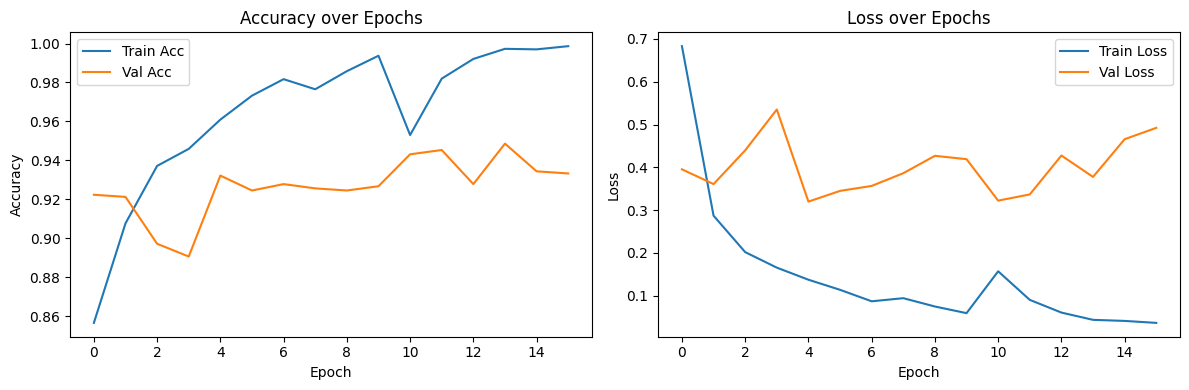

In [29]:
# Learning curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(full_hist['accuracy'], label='Train Acc')
plt.plot(full_hist['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(full_hist['loss'], label='Train Loss')
plt.plot(full_hist['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

In [30]:
# Evaluate on test
test_loss, test_acc = best_model.evaluate(test_ds_pp, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

✅ Test Accuracy: 0.9275 | Test Loss: 0.3833


In [31]:
# Predictions & metrics
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).astype(int)
y_prob = best_model.predict(test_ds_pp, verbose=0).ravel()
y_pred = (y_prob > 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

In [32]:
# ROC-AUC: ensure labels are 0/1; y_prob are probabilities for class "1"
try:
    rocauc = roc_auc_score(y_true, y_prob)
except ValueError:
    rocauc = float('nan')

print("\n📊 Metrics (Test)")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {rocauc:.4f}")


📊 Metrics (Test)
Accuracy : 0.9275
Precision: 0.9321
Recall   : 0.9321
F1-score : 0.9321
ROC-AUC  : 0.9807


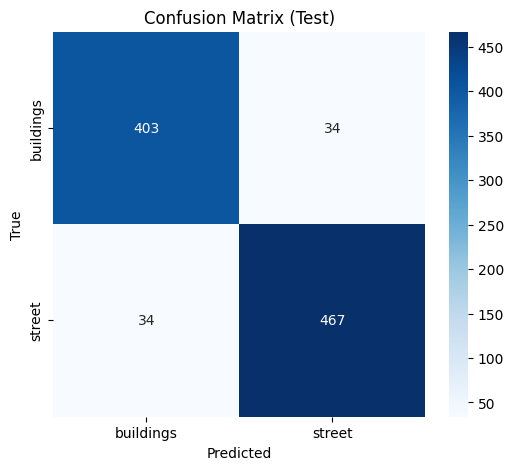


📋 Classification Report (Test):
              precision    recall  f1-score   support

   buildings     0.9222    0.9222    0.9222       437
      street     0.9321    0.9321    0.9321       501

    accuracy                         0.9275       938
   macro avg     0.9272    0.9272    0.9272       938
weighted avg     0.9275    0.9275    0.9275       938



In [33]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("\n📋 Classification Report (Test):")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

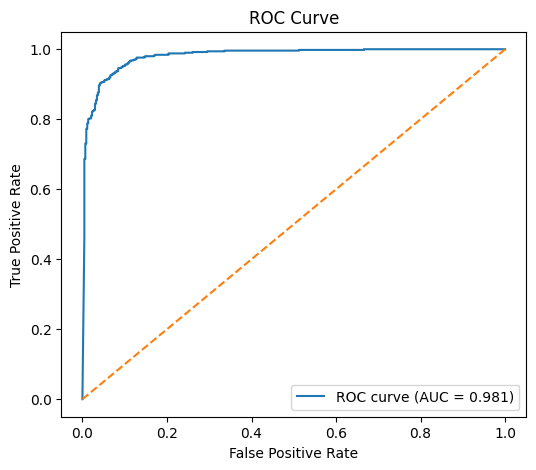

In [34]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(loc="lower right")
plt.show()

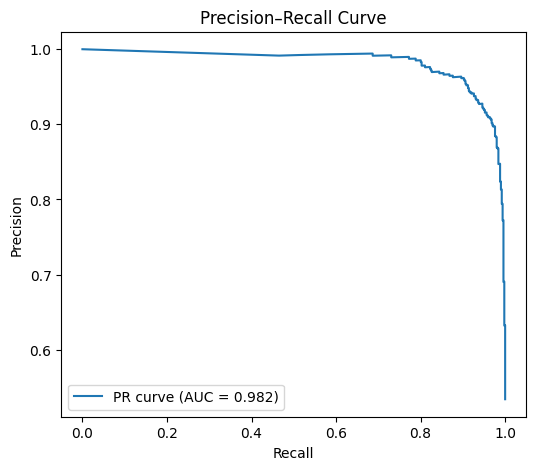

In [35]:
# Precision-Recall Curve
prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_prob)
pr_auc_val = auc(rec_vals, prec_vals)
plt.figure(figsize=(6,5))
plt.plot(rec_vals, prec_vals, label=f'PR curve (AUC = {pr_auc_val:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall Curve'); plt.legend(loc="lower left")
plt.show()

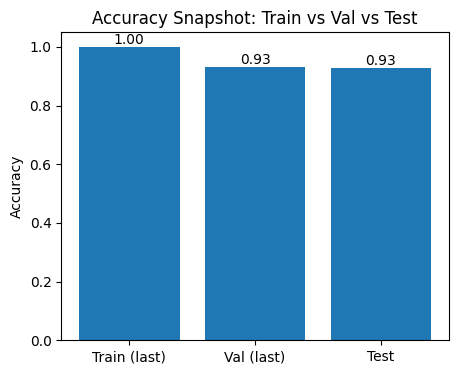

In [36]:
# Snapshot bars (Train last, Val last, Test)
final_train_acc = full_hist['accuracy'][-1]
final_val_acc   = full_hist['val_accuracy'][-1]
plt.figure(figsize=(5,4))
plt.bar(['Train (last)','Val (last)','Test'], [final_train_acc, final_val_acc, test_acc])
plt.title('Accuracy Snapshot: Train vs Val vs Test')
plt.ylabel('Accuracy')
for i, v in enumerate([final_train_acc, final_val_acc, test_acc]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.ylim(0, 1.05)
plt.show()

In [37]:
# 8) Save & Quick Predict
best_model.save(FINAL_MODEL_PATH)
print(f"💾 Final model saved to: {FINAL_MODEL_PATH}")

reloaded = keras.models.load_model(FINAL_MODEL_PATH)
print("♻️ Reloaded model ready.")

from tensorflow.keras.preprocessing import image

def predict_and_show(model, img_path, class_names):
    img = image.load_img(img_path, target_size=IMAGE_SIZE)
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    prob = float(model.predict(arr, verbose=0)[0][0])
    label = class_names[1] if prob > 0.5 else class_names[0]
    plt.imshow(image.load_img(img_path))
    plt.title(f"Predicted: {label} (score={prob:.2f})",
              color=("green" if prob > 0.5 else "red"))
    plt.axis("off")
    plt.show()

💾 Final model saved to: /content/vgg16_final.keras
♻️ Reloaded model ready.


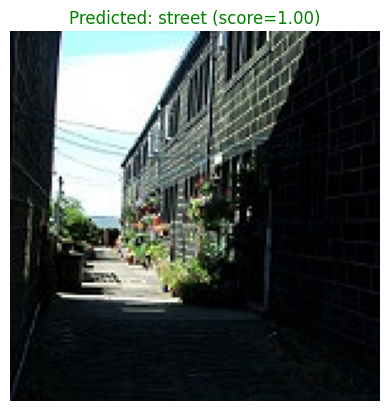

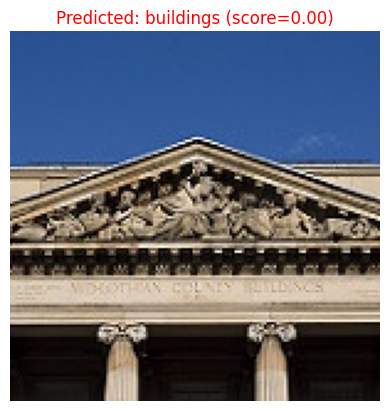

In [38]:
# Example test images
img1 = os.path.join(test_dir, "street", "20079.jpg")
img2 = os.path.join(test_dir, "buildings", "20073.jpg")
for p in [img1, img2]:
    if os.path.exists(p):
        predict_and_show(reloaded, p, class_names)
    else:
        print(f"⚠️ Sample image not found: {p}")